Con esto voy a generar STFT de muestras de 100 ms

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, istft
import scipy.io.wavfile as wav
import os

In [12]:
fs, data = wav.read("GRWL ROAR ANGRY.wav")

print("frecuencia de muestreo:", fs)
print("numero de muestras:", len(data))
print("duracion:", len(data)/fs, "segundos")

frecuencia de muestreo: 44100
numero de muestras: 158524
duracion: 3.5946485260770977 segundos


La idea solo es procesar una cantidad de muestras potencia de 2 cercana a 100 ms  
Mi calculo fue:

$$ \frac{4096}{44100} \approx 0.092 sec$$

Con esto tenemos que con las 158524 muestras del audio se pueden sacar 38 muestras de STFT, estas van a componer la base de datos

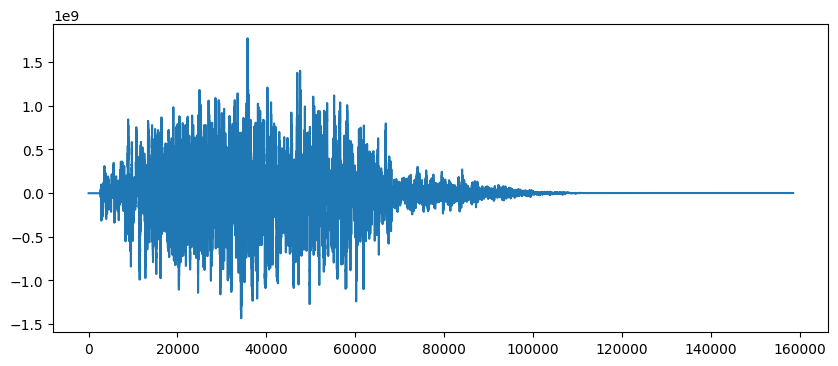

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(data)
plt.show()

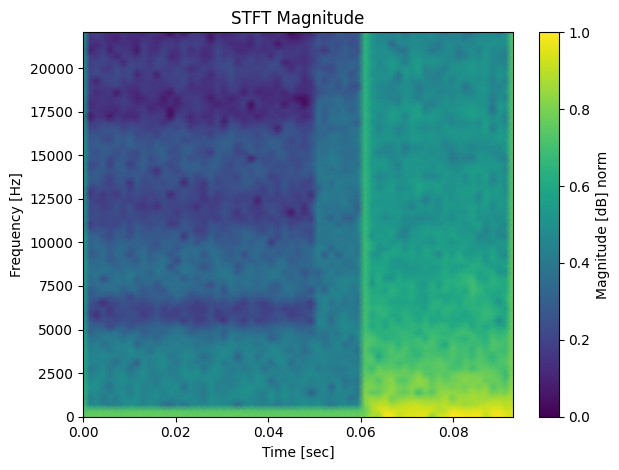

In [93]:
data_test = data[:4096]  # Limit to 4096 samples for STFT

f, t, Zxx = stft(data_test, fs=fs ,nperseg= 128, noverlap= 64, nfft= 128)

Zxx = np.abs(Zxx)  
Zxx_db = 20 * np.log10(Zxx + 1e-6) 

min_val = np.min(Zxx_db)
max_val = np.max(Zxx_db)

Zxx_db_norm = (Zxx_db - min_val) / (max_val - min_val)  

pcm = plt.pcolormesh(t, f, Zxx_db_norm, shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
cbar = plt.colorbar(pcm, label='Magnitude [dB] norm') 
plt.tight_layout()
plt.show()

In [94]:
print("minimo:", np.min(Zxx_db_norm))
print("maximo:", np.max(Zxx_db_norm))
os.makedirs("dataset")

minimo: 0.0
maximo: 1.0


In [23]:
muestras = len(data)// 4096

print(muestras)

38


In [37]:
lista_magnitud = []
lista_fase = []
min_max_values = []
for i in range(muestras):
    bloque = data[i * 4096: (i+1)* 4096]
    f, t, Zxx = stft(bloque, fs=fs, nperseg=128, noverlap=64, nfft=128)

    Zxx_mag = np.abs(Zxx)
    Zxx_phase = np.angle(Zxx)
    
    Zxx_mag = 20 * np.log10(Zxx_mag + 1e-6)
    min_val = np.min(Zxx_mag)
    max_val = np.max(Zxx_mag)
    Zxx_mag = (Zxx_mag - min_val) / (max_val - min_val)

    min_max_values.append((min_val, max_val))
    lista_magnitud.append(Zxx_mag)
    lista_fase.append(Zxx_phase)

np.save("dataset/magnitudes.npy", np.array(lista_magnitud))
np.save("dataset/fases.npy", np.array(lista_fase))
np.save("dataset/min_max_values.npy", np.array(min_max_values))


Ahora la voy a abrir a ver que onda

dataset shape: (38, 65, 65)


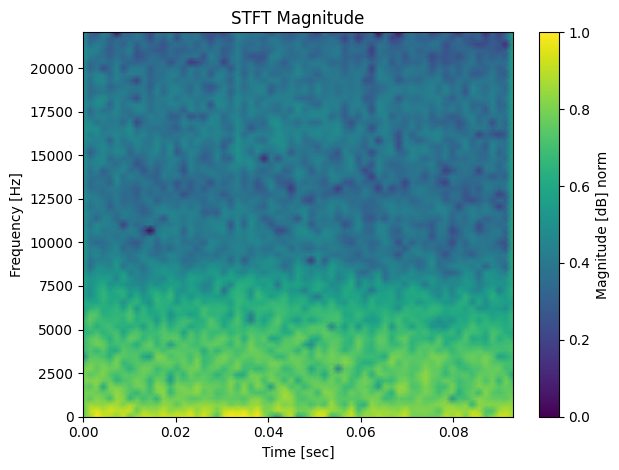

In [38]:
dataset = np.load("dataset/magnitudes.npy")

print("dataset shape:", dataset.shape)

pcm = plt.pcolormesh(t, f, dataset[10], shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
cbar = plt.colorbar(pcm, label='Magnitude [dB] norm') 
plt.tight_layout()
plt.show()

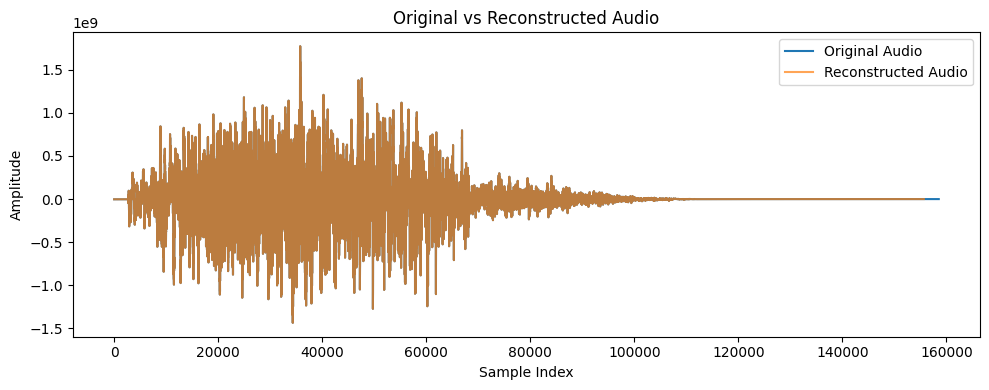

El error cuadratico medio entre el audio original y el reconstruido es: 7.675084436523293e-11


In [39]:
mags = np.load("dataset/magnitudes.npy")
phases = np.load("dataset/fases.npy")
min_max_values = np.load("dataset/min_max_values.npy")

audio_reconstruido = []

for magnitud, fase, (min_val, max_val) in zip(mags, phases, min_max_values):
    magnitud = magnitud * (max_val - min_val) + min_val
    magnitud = 10 ** (magnitud / 20)  # Convert dB back to linear scale
    Zxx = magnitud * np.exp(1j * fase)
    
    _, audio_bloque = istft(Zxx, fs=fs, nperseg=128, noverlap=64, nfft=128)
    
    audio_reconstruido.append(audio_bloque)

audio_reconstruido = np.concatenate(audio_reconstruido)
wav.write("audio_reconstruido.wav", fs, audio_reconstruido.astype(np.float32))

#voy a comprare el audio original con el reconstruido en un plot

plt.figure(figsize=(10, 4))
plt.plot(data, label='Original Audio')
plt.plot(audio_reconstruido, label='Reconstructed Audio', alpha=0.7)
plt.title('Original vs Reconstructed Audio')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

print("El error cuadratico medio entre el audio original y el reconstruido es:", np.mean((data[:len(audio_reconstruido)] - audio_reconstruido) ** 2))